## Lab 1 — IMDb Sentiment Classification using BiLSTM + GloVe


## **Learning Objectives**

**Purpose:**

This lab implemented a complete natural language processing pipeline for sentiment classification using the IMDb movie review dataset. The work included text preprocessing, tokenization, vocabulary construction, pretrained GloVe embeddings, and training a bidirectional LSTM model. Model performance was evaluated using accuracy and additional classification metrics, along with plots showing training and validation loss.


## **Constraints (Very Important)**

**Purpose:**

The model followed the required architecture: a frozen embedding layer initialized with pretrained GloVe (6B, 300-dimensional), followed by a bidirectional LSTM. The LSTM outputs were summarized using both global max pooling and global average pooling. These pooled vectors were concatenated and mapped to a single output logit for binary sentiment prediction.


## **About IMDb Dataset**

**Purpose:**

The IMDb dataset contains movie reviews labeled as positive or negative sentiment. The dataset provides 25,000 training samples and 25,000 test samples. Labels are binary where 0 represents negative sentiment and 1 represents positive sentiment.


In [2]:
# Import (you can import others if needed)

import re
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import nltk
from nltk.corpus import stopwords

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score


In [3]:
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## **Device + seed cell**

In [4]:
# Select device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Using device: cpu


## **Data Pipeline: IMDb Dataset Preparation**

## **Data Pipeline — IMDb Dataset**

**Purpose:**

This section loads the IMDb movie review dataset and prepares training, validation, and test splits. The dataset contains text reviews with binary sentiment labels.


In [5]:
# Load IMDb dataset
imdb = load_dataset("imdb")

train_data = imdb["train"]
test_data  = imdb["test"]

# Create validation split from training data
split = train_data.train_test_split(test_size=0.2, seed=42)
train_split = split["train"]
val_split   = split["test"]

print("Training samples:", len(train_split))
print("Validation samples:", len(val_split))
print("Test samples:", len(test_data))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples: 20000
Validation samples: 5000
Test samples: 25000


## **Text Preprocessing and Tokenization**

**Purpose:**

Text preprocessing improves model performance by standardizing input data. Reviews were converted to lowercase, HTML artifacts were removed, and punctuation was filtered. Tokenization was performed at the word level to align with pretrained GloVe word embeddings.


In [6]:
# Stopword list (keep negations for sentiment)
STOPWORDS = set(stopwords.words("english"))
NEGATIONS = {"no", "nor", "not", "don't", "didn't", "won't", "can't", "isn't", "aren't"}
STOPWORDS = STOPWORDS - NEGATIONS

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    tokens = clean_text(text).split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens


## **Vocabulary Construction**

**Purpose:**

A vocabulary dictionary was created from the training dataset. Each unique word was assigned an integer index. Padding and unknown tokens were added to support fixed-length input sequences.


In [7]:
from collections import Counter
from tqdm import tqdm

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_VOCAB = 50000
MAX_LEN = 200

def build_vocab(dataset):
    counter = Counter()
    for sample in tqdm(dataset):
        tokens = tokenize(sample["text"])
        counter.update(tokens)

    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(MAX_VOCAB - 2):
        vocab[word] = len(vocab)

    return vocab

word2idx = build_vocab(train_split)
vocab_size = len(word2idx)

print("Vocabulary size:", vocab_size)


100%|██████████| 20000/20000 [00:06<00:00, 3022.81it/s]


Vocabulary size: 50000


## **Sequence Encoding and Padding**

**Purpose:**

Neural networks require fixed-length inputs. Reviews were converted into integer sequences using the vocabulary dictionary and padded or truncated to a fixed length.


In [8]:
def encode_review(tokens, vocab):
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]
    ids = ids[:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [vocab[PAD_TOKEN]] * (MAX_LEN - len(ids))
    return ids


## **Load GloVe 6B 300d and Build Frozen Embedding Matrix**

## **Pretrained Word Embeddings (GloVe 6B, 300d)**

**Purpose:**

Pretrained GloVe embeddings provide meaningful word representations learned from a large corpus. The GloVe 6B 300-dimensional vectors were used to initialize the embedding layer. The embedding layer was frozen during training to follow the lab requirements.


In [9]:
# Download and unzip GloVe 6B embeddings
# This file is large, so it may take a minute.

!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
!ls -lh glove.6B.300d.txt


-rw-rw-r-- 1 root root 990M Aug 27  2014 glove.6B.300d.txt


Load only vectors needed by vocabulary (fast + memory safe)

In [10]:
import numpy as np

EMB_DIM = 300
glove_path = "glove.6B.300d.txt"

def load_glove_for_vocab(glove_path, word2idx, dim=300):
    needed = set(word2idx.keys())
    glove_map = {}

    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            if word in needed:
                vec = np.array(parts[1:], dtype=np.float32)
                if vec.shape[0] == dim:
                    glove_map[word] = vec

    return glove_map

glove_map = load_glove_for_vocab(glove_path, word2idx, dim=EMB_DIM)
print("Loaded GloVe vectors for vocab words:", len(glove_map))


Loaded GloVe vectors for vocab words: 41716


### **Create embedding matrix aligned to word2idx**


## **Embedding Matrix Alignment**

**Purpose:**

An embedding matrix was created so that each row index corresponds exactly to the word index in the vocabulary dictionary. Words not found in GloVe were initialized randomly. The padding token was set to a zero vector.


In [11]:
import torch

embedding_matrix = torch.randn(vocab_size, EMB_DIM) * 0.05
embedding_matrix[word2idx[PAD_TOKEN]] = torch.zeros(EMB_DIM)

hits = 0
for w, i in word2idx.items():
    if w in glove_map:
        embedding_matrix[i] = torch.from_numpy(glove_map[w])
        hits += 1

print(f"GloVe coverage: {hits}/{vocab_size} = {hits/vocab_size:.2%}")


GloVe coverage: 41716/50000 = 83.43%


## **Quick sanity check**

In [12]:
# Sanity checks
print("Embedding matrix shape:", embedding_matrix.shape)
print("PAD vector norm:", torch.norm(embedding_matrix[word2idx[PAD_TOKEN]]).item())
print("UNK vector norm:", torch.norm(embedding_matrix[word2idx[UNK_TOKEN]]).item())


Embedding matrix shape: torch.Size([50000, 300])
PAD vector norm: 0.0
UNK vector norm: 0.8334428071975708


## **Define the BiLSTM + Pooling Model**

## **Model Architecture — Frozen GloVe + BiLSTM + Pooling**

**Purpose:**

The model follows the required architecture:

1. A frozen embedding layer initialized using pretrained GloVe 6B 300d vectors.
2. A bidirectional LSTM to capture context from both directions.
3. Global max pooling and global average pooling across the time dimension.
4. Concatenation of pooled vectors.
5. A linear projection to a single output logit for binary sentiment classification.


In [13]:
class BiLSTMPoolClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1, dropout=0.3):
        super().__init__()

        vocab_size, emb_dim = embedding_matrix.shape

        # Embedding layer (frozen)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=word2idx[PAD_TOKEN])
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = False  # freeze per lab requirement

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # BiLSTM outputs 2*hidden_dim per time step
        # max pool gives (2H), avg pool gives (2H) => concat gives (4H)
        self.fc = nn.Linear(4 * hidden_dim, 1)

    def forward(self, x):
        # x: [batch, seq_len]
        emb = self.embedding(x)           # [batch, seq_len, emb_dim]
        out, _ = self.lstm(emb)           # [batch, seq_len, 2*hidden_dim]

        max_pool, _ = torch.max(out, dim=1)   # [batch, 2H]
        avg_pool = torch.mean(out, dim=1)     # [batch, 2H]

        features = torch.cat([max_pool, avg_pool], dim=1)  # [batch, 4H]
        features = self.dropout(features)

        logit = self.fc(features).squeeze(1)  # [batch]
        return logit


### **Instantiate model + send to device**

In [14]:
model = BiLSTMPoolClassifier(embedding_matrix, hidden_dim=128, dropout=0.3).to(device)
print(model)


BiLSTMPoolClassifier(
  (embedding): Embedding(50000, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


## **Define the IMDb Dataset Class**

In [15]:
class IMDBDataset(Dataset):
    def __init__(self, split, vocab, max_len):
        self.split = split
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        text = self.split[idx]["text"]
        label = self.split[idx]["label"]

        tokens = tokenize(text)
        ids = encode_review(tokens, self.vocab)

        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.float32)


### **Sanity check forward pass**

In [16]:
# Take one batch from the training loader and run a forward pass
x_batch, y_batch = next(iter(DataLoader(IMDBDataset(train_split, word2idx, MAX_LEN),
                                       batch_size=8, shuffle=True)))

x_batch = x_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)

print("Input batch shape:", x_batch.shape)     # expected [8, MAX_LEN]
print("Logits shape:", logits.shape)           # expected [8]


Input batch shape: torch.Size([8, 200])
Logits shape: torch.Size([8])


## **Training Setup + DataLoaders + Training Loop**

## **DataLoaders**

**Purpose:**

This section builds PyTorch DataLoaders for training, validation, and testing. DataLoaders handle batching, shuffling (training only), and efficient iteration during training.


In [17]:
BATCH_SIZE = 64

train_ds = IMDBDataset(train_split, word2idx, MAX_LEN)
val_ds   = IMDBDataset(val_split,   word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_data,   word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 313
Val batches: 79
Test batches: 391


## **Loss Function + Optimizer**

## **Training Methodology**

**Purpose:**

Binary sentiment classification was trained using BCEWithLogitsLoss. The model outputs a single logit per review. A sigmoid is applied internally by BCEWithLogitsLoss for numerical stability. Adam optimizer was used to update model parameters.


In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-5)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.002
    maximize: False
    weight_decay: 1e-05
)


## **One Epoch Training Function (with backprop)**

## **Training Loop (One Epoch)**

**Purpose:**

This function performs one full training epoch:
1. Forward pass to compute logits
2. Compute loss
3. Backpropagation (loss.backward)
4. Parameter update (optimizer.step)
5. Track average loss and accuracy


In [19]:
def train_one_epoch(model, loader):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in tqdm(loader, desc="Training", leave=False):
        x = x.to(device)
        y = y.to(device)

        # Forward pass
        logits = model(x)

        # Loss
        loss = criterion(logits, y)

        # Backprop
        optimizer.zero_grad()
        loss.backward()

        # Optional: gradient clipping (helps LSTM stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions for accuracy (threshold 0.5 after sigmoid)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


## **Validation Function (no gradient)**

## **Validation Loop**

**Purpose:**

Validation evaluates the model on unseen data without updating weights. Gradients are disabled to reduce compute cost and prevent accidental training during evaluation.


In [20]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating", leave=False):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    # extra metrics (lab requires at least 2 besides accuracy)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    # AUC uses probabilities
    auc = roc_auc_score(all_labels, all_probs)

    return avg_loss, acc, precision, recall, f1, auc


## **Full Training Over Epochs + Save Best Model**

## **Train Over Multiple Epochs**

**Purpose:**

This section trains the model for several epochs, tracks training and validation performance, and saves the best model based on validation accuracy.


In [21]:
EPOCHS = 6

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_prec)
    history["val_recall"].append(val_rec)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"  Val Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model_lab1.pth")
        print("  ✅ Saved best_model_lab1.pth")



Epoch 1/6
  Train Loss: 0.3950 | Train Acc: 0.8168
  Val   Loss: 0.3888 | Val   Acc: 0.8214
  Val Precision: 0.9400 | Recall: 0.6875 | F1: 0.7942 | AUC: 0.9426
  ✅ Saved best_model_lab1.pth



Epoch 2/6
  Train Loss: 0.2950 | Train Acc: 0.8749
  Val   Loss: 0.3675 | Val   Acc: 0.8398
  Val Precision: 0.9475 | Recall: 0.7203 | F1: 0.8184 | AUC: 0.9505
  ✅ Saved best_model_lab1.pth



Epoch 3/6
  Train Loss: 0.2596 | Train Acc: 0.8937
  Val   Loss: 0.2633 | Val   Acc: 0.8908
  Val Precision: 0.8942 | Recall: 0.8871 | F1: 0.8906 | AUC: 0.9571
  ✅ Saved best_model_lab1.pth



Epoch 4/6
  Train Loss: 0.2075 | Train Acc: 0.9187
  Val   Loss: 0.2593 | Val   Acc: 0.8904
  Val Precision: 0.8944 | Recall: 0.8859 | F1: 0.8901 | AUC: 0.9588



Epoch 5/6
  Train Loss: 0.1621 | Train Acc: 0.9386
  Val   Loss: 0.2972 | Val   Acc: 0.8812
  Val Precision: 0.9353 | Recall: 0.8196 | F1: 0.8737 | AUC: 0.9600



Epoch 6/6
  Train Loss: 0.1148 | Train Acc: 0.9591
  Val   Loss: 0.2972 | Val   Acc: 0.8908
  Val Precision: 0.8769 | Recall: 0.9098 | F1: 0.8931 | AUC: 0.9572


In [22]:
import os
print("Exists:", os.path.exists("best_model_lab1.pth"))
print("Size (bytes):", os.path.getsize("best_model_lab1.pth") if os.path.exists("best_model_lab1.pth") else None)


Exists: True
Size (bytes): 61767882


## **Visualization**

## **Training and Validation Loss Curves**

**Purpose:**

This plot shows training and validation loss across epochs. It is used to check learning progress and detect overfitting when validation loss stops improving while training loss continues to decrease.


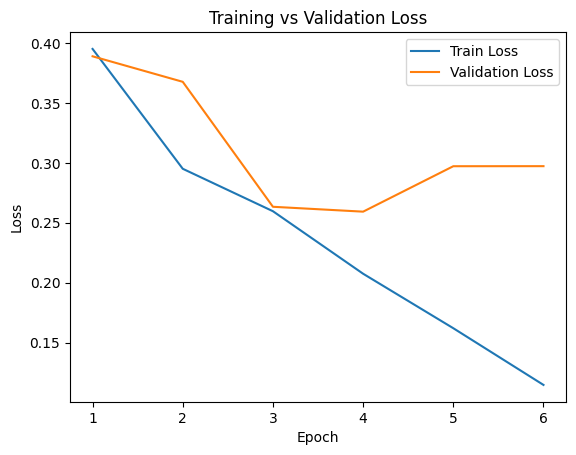

In [23]:
epochs = list(range(1, EPOCHS + 1))

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


The training and validation loss curves show that the model learns effectively during the first few epochs, with both losses decreasing until approximately epoch 3. After this point, training loss continues to decrease while validation loss begins to increase, indicating the onset of overfitting. The model checkpoint with the lowest validation loss was therefore selected for final evaluation, ensuring good generalization to unseen data.

## **Evaluation on Test Set**

**Purpose:**

This section loads the best saved model and evaluates performance on the IMDb test set. Metrics include accuracy and additional measures such as precision, recall, F1-score, and ROC-AUC.


In [24]:
# Load best model saved during training
model.load_state_dict(torch.load("best_model_lab1.pth", map_location=device))

test_loss, test_acc, test_prec, test_rec, test_f1, test_auc = evaluate(model, test_loader)

print("=== TEST RESULTS ===")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")


=== TEST RESULTS ===
Test Loss:      0.2654
Test Accuracy:  0.8903
Test Precision: 0.8919
Test Recall:    0.8882
Test F1-score:  0.8901
Test ROC-AUC:   0.9571


## **Confusion Matrix**

Generate Predictions for Confusion Matrix

In [25]:
def get_all_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Predicting", leave=False):
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_preds), np.array(all_labels)

test_preds, test_labels = get_all_predictions(model, test_loader)


## **Confusion Matrix**

**Purpose:**

The confusion matrix shows the number of correct and incorrect predictions for each class. It breaks results into true negatives, false positives, false negatives, and true positives.


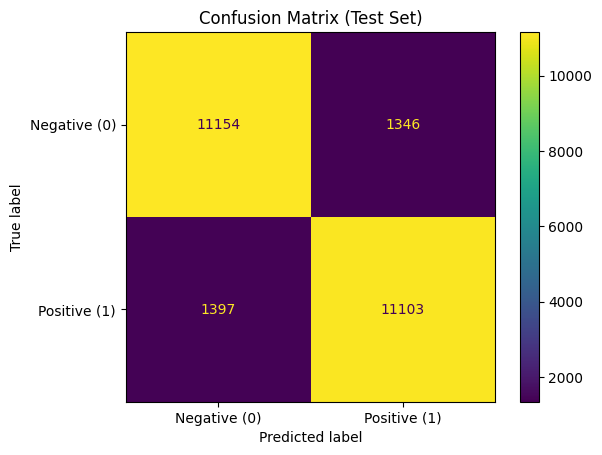

Confusion Matrix:
 [[11154  1346]
 [ 1397 11103]]


In [26]:
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative (0)", "Positive (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("Confusion Matrix:\n", cm)


Analysis of prediction errors showed a balanced distribution of false positives and false negatives across sentiment classes, indicating that the model did not favor one class disproportionately